# Task 2 — Time Series Forecasting Models

**GMF Investments · Week 9**

Forecast **TSLA** Adjusted Close. This notebook covers data preparation
(chronological split) and the **ARIMA/SARIMA** model; the LSTM and the final
model comparison follow in later sections.

**Split (critical for time series — no shuffling):** train 2015–2024, test 2025–2026.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, forecasting as fc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Prepare Data — Chronological Train/Test Split

Full : 2015-01-02 -> 2026-06-29  (n=2888)
Train: 2015-01-02 -> 2024-12-31  (n=2516)
Test : 2025-01-02 -> 2026-06-29  (n=372)


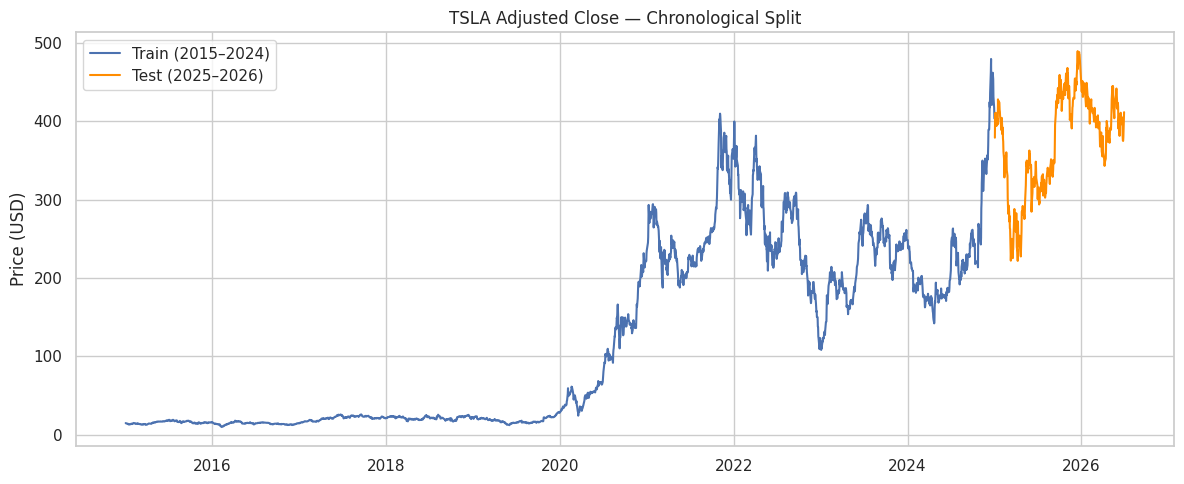

In [2]:
target = fc.load_target()  # TSLA Adj Close
train, test = fc.chronological_split(target)

print(f"Full : {target.index.min().date()} -> {target.index.max().date()}  (n={len(target)})")
print(f"Train: {train.index.min().date()} -> {train.index.max().date()}  (n={len(train)})")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()}  (n={len(test)})")

fig, ax = plt.subplots()
ax.plot(train.index, train, label="Train (2015–2024)")
ax.plot(test.index, test, label="Test (2025–2026)", color="darkorange")
ax.set_title("TSLA Adjusted Close — Chronological Split")
ax.set_ylabel("Price (USD)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "07_train_test_split.png", dpi=120)
plt.show()

## 2. Identify Order — ACF / PACF
Task 1 showed the price level is **non-stationary** (ADF p > 0.05), so we
difference once (`d = 1`) and inspect the ACF/PACF of the differenced series to
sanity-check candidate AR (`p`, from PACF) and MA (`q`, from ACF) orders. This
corroborates the automated search below.

ADF p-value, differenced train: 8.734e-17  (stationary => d=1)


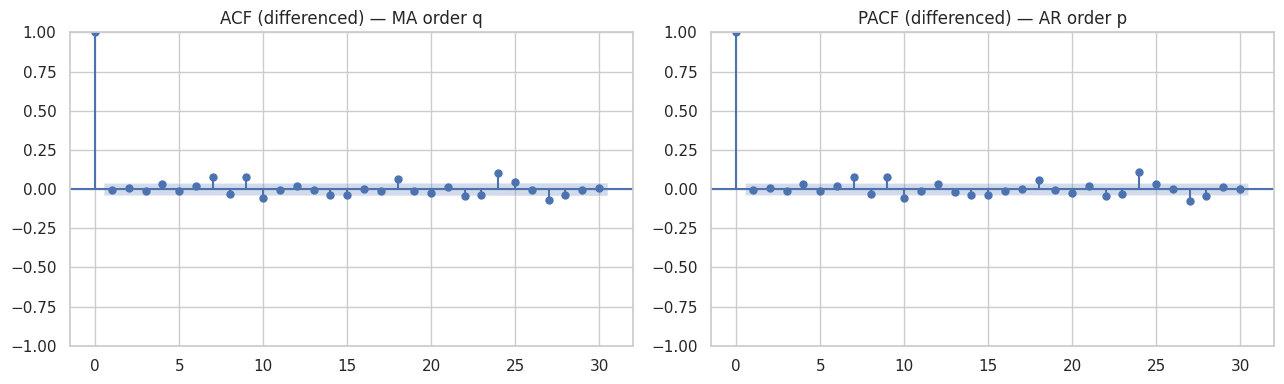

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

diff = train.diff().dropna()
print(f"ADF p-value, differenced train: {adfuller(diff)[1]:.3e}  (stationary => d=1)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(diff, lags=30, ax=axes[0]); axes[0].set_title("ACF (differenced) — MA order q")
plot_pacf(diff, lags=30, ax=axes[1], method="ywm"); axes[1].set_title("PACF (differenced) — AR order p")
fig.tight_layout(); fig.savefig(FIG_DIR / "08_acf_pacf.png", dpi=120)
plt.show()

## 3. Auto-ARIMA Grid Search
`pmdarima.auto_arima` searches (p, d, q) by AIC. Daily equity prices have no
fixed calendar seasonality, so we fit **non-seasonal** ARIMA as the primary
model (a weekly `m=5` SARIMA on ~2,500 points is expensive and rarely improves
on this data). `d` is selected automatically and is expected to be 1, matching
the differencing above.

In [4]:
arima = fc.fit_auto_arima(train, seasonal=False, trace=True)
print("\nSelected order (p, d, q):", arima.order)
print(arima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.12 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.03 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.25 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.617 seconds

Selected order (p, d, q): (0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        15:12:54   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.

## 4. Forecast the Test Period
Static multi-step forecast over the full test horizon with 95% confidence intervals.

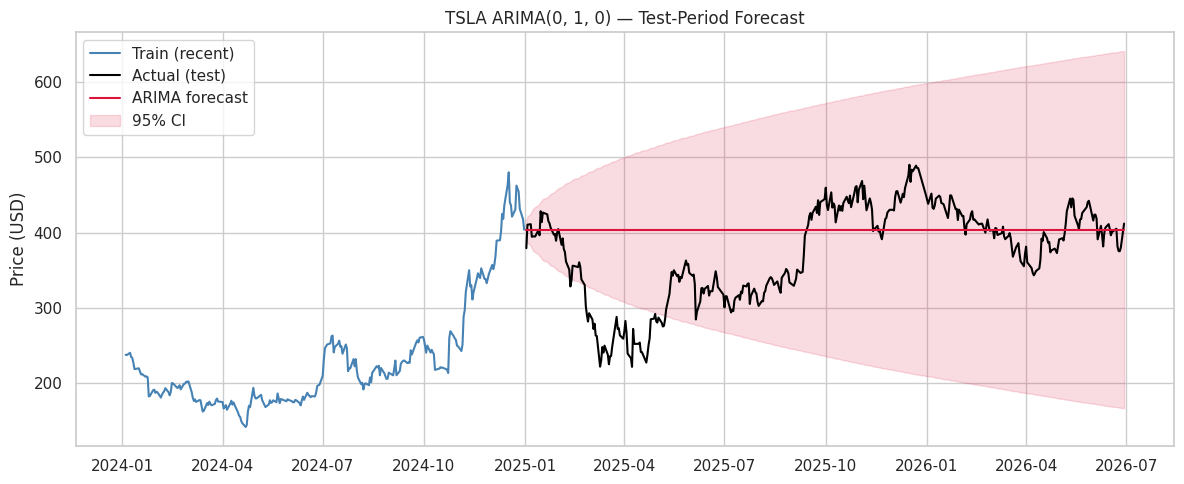

In [5]:
fc_mean, conf = fc.arima_forecast(arima, n_periods=len(test), index=test.index)

fig, ax = plt.subplots()
ax.plot(train.index[-250:], train.iloc[-250:], label="Train (recent)", color="steelblue")
ax.plot(test.index, test, label="Actual (test)", color="black")
ax.plot(fc_mean.index, fc_mean, label="ARIMA forecast", color="crimson")
ax.fill_between(conf.index, conf["lower"], conf["upper"], color="crimson", alpha=0.15, label="95% CI")
ax.set_title(f"TSLA ARIMA{arima.order} — Test-Period Forecast")
ax.set_ylabel("Price (USD)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "09_arima_forecast.png", dpi=120)
plt.show()

## 5. Evaluate — MAE / RMSE / MAPE

In [6]:
arima_metrics = fc.evaluate(test.values, fc_mean.values)
print("ARIMA test metrics:")
for k, v in arima_metrics.items():
    print(f"  {k}: {v:.4f}")

# Persist for the later model-comparison table.
metrics_df = pd.DataFrame({f"ARIMA{arima.order}": arima_metrics}).T
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(config.PROCESSED_DIR / "model_metrics.csv")
metrics_df.round(4)

ARIMA test metrics:
  MAE: 54.4412
  RMSE: 70.5393
  MAPE: 17.2407


,MAE,RMSE,MAPE
"ARIMA(0, 1, 0)",54.4412,70.5393,17.2407


## Notes

- **Order = ARIMA(0,1,0) — a random walk.** `auto_arima` minimized AIC and found no AR or MA terms improve on differencing alone. This is the classic **Efficient Market Hypothesis** result: the best statistical guess for tomorrow's price is today's price. `d=1` matches the differencing needed for stationarity (Task 1).
- **Consequence:** the static multi-step forecast is a flat line at the last observed price, and the 95% CI fans out as √horizon — quantifying how quickly certainty decays. MAPE ≈ 17% over the ~18-month test window reflects TSLA's large drift away from that flat forecast.
- **Seasonality:** No fixed calendar seasonality in daily equity prices, so a non-seasonal ARIMA is used; SARIMA `(P, D, Q, m)` would be the extension for data with a repeating cycle.
- **Next:** the LSTM can, in principle, adapt to trend/momentum a random walk cannot — the comparison (MAE/RMSE/MAPE) will show whether that holds here.

## 6. LSTM Model

A 2-layer LSTM on 60-day windows of MinMax-scaled prices (LSTM(50) → Dropout → LSTM(50) → Dropout → Dense(1)). Test predictions use walk-forward **one-step-ahead** forecasting: each day is predicted from the true trailing 60 days, then inverse-transformed back to price.

I0000 00:00:1783253575.619579   13261 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783253575.670573   13261 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783253578.842018   13261 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

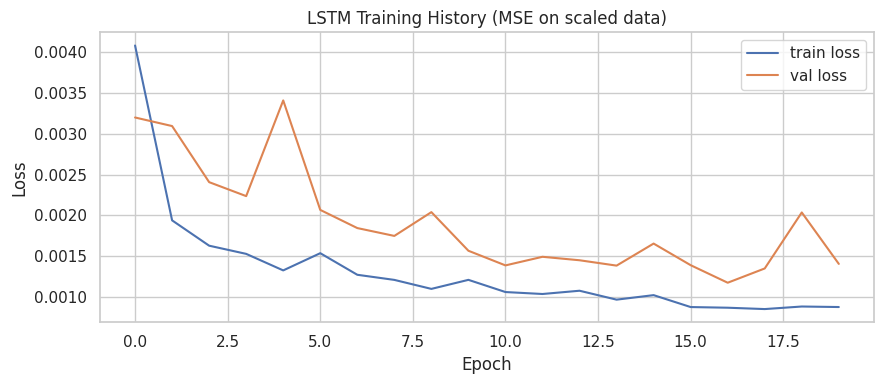

In [7]:
fc.tf_set_seed()
lstm_pred, lstm_model, history, scaler = fc.run_lstm_pipeline(
    train, test, window=config.LSTM_WINDOW, units=50, layers=2,
    epochs=20, batch_size=32, verbose=0,
)
lstm_model.summary()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history['loss'], label='train loss')
ax.plot(history.history['val_loss'], label='val loss')
ax.set_title('LSTM Training History (MSE on scaled data)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / '13_lstm_loss.png', dpi=120)
plt.show()

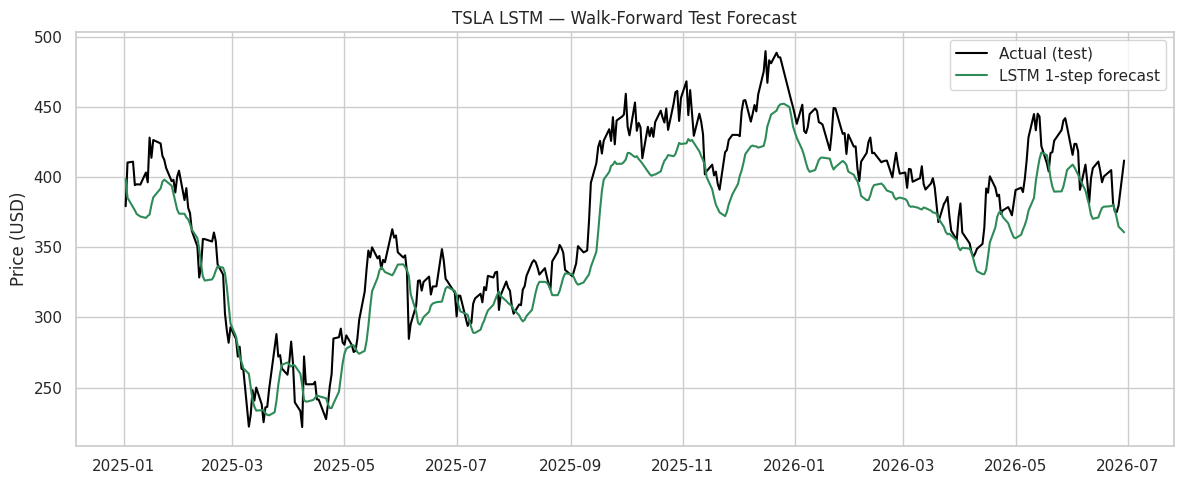

LSTM test metrics: {'MAE': 21.6364, 'RMSE': 25.8432, 'MAPE': 5.6975}


In [8]:
fig, ax = plt.subplots()
ax.plot(test.index, test, label='Actual (test)', color='black')
ax.plot(lstm_pred.index, lstm_pred, label='LSTM 1-step forecast', color='seagreen')
ax.set_title('TSLA LSTM — Walk-Forward Test Forecast')
ax.set_ylabel('Price (USD)'); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / '14_lstm_forecast.png', dpi=120)
plt.show()

lstm_metrics = fc.evaluate(test.values, lstm_pred.values)
print('LSTM test metrics:', {k: round(v, 4) for k, v in lstm_metrics.items()})

## 7. Model Comparison

To compare fairly we separate **model quality** from **forecast horizon**.
The ARIMA(0,1,0) result in §5 is a *static multi-step* forecast (one flat line over 18 months). Its natural *one-step* counterpart is the **random walk** — predict tomorrow with today's price — which is the like-for-like baseline for the one-step LSTM.

In [9]:
# One-step random-walk baseline: prediction[t] = actual price[t-1]
naive_pred = target.shift(1).loc[test.index]
naive_metrics = fc.evaluate(test.values, naive_pred.values)

comparison = pd.DataFrame({
    'ARIMA(0,1,0) · multi-step': arima_metrics,
    'Random Walk · 1-step': naive_metrics,
    'LSTM · 1-step': lstm_metrics,
}).T[['MAE', 'RMSE', 'MAPE']]
comparison.to_csv(config.PROCESSED_DIR / 'model_metrics.csv')
display(comparison.round(4))

,MAE,RMSE,MAPE
"ARIMA(0,1,0) · multi-step",54.4412,70.5393,17.2407
Random Walk · 1-step,9.4563,12.2342,2.6481
LSTM · 1-step,21.6364,25.8432,5.6975


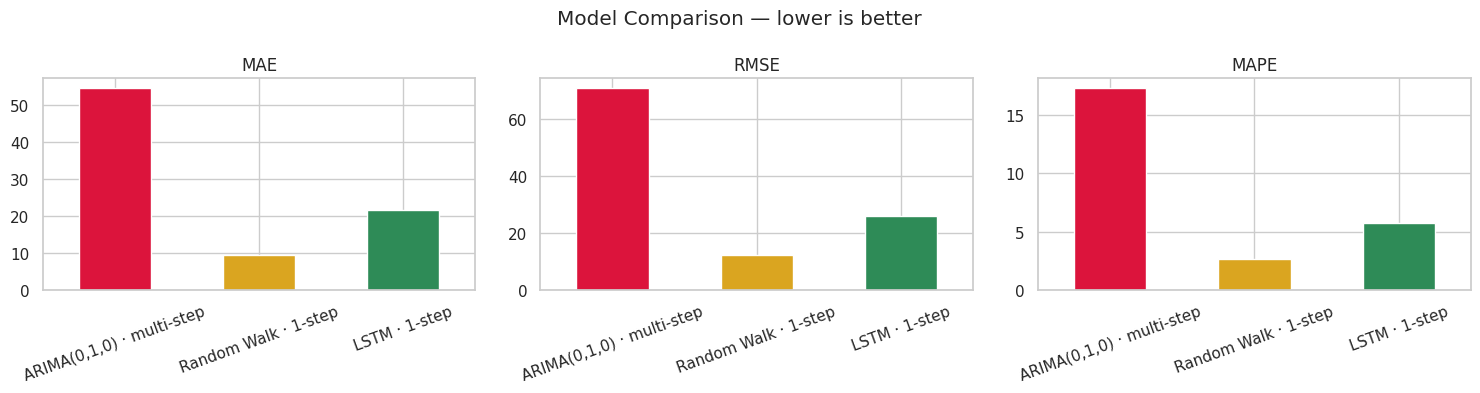

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    comparison[metric].plot.bar(ax=ax, color=['crimson', 'goldenrod', 'seagreen'])
    ax.set_title(metric); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
fig.suptitle('Model Comparison — lower is better')
fig.tight_layout(); fig.savefig(FIG_DIR / '15_model_comparison.png', dpi=120)
plt.show()

## 8. Model Selection Rationale

Test-set results (TSLA, 2025–2026):

| Model | MAE | RMSE | MAPE |
| :--- | ---: | ---: | ---: |
| ARIMA(0,1,0) · multi-step | 54.44 | 70.54 | 17.24% |
| **Random Walk · 1-step** | **9.46** | **12.23** | **2.65%** |
| LSTM · 1-step | 21.64 | 25.84 | 5.70% |

- **Horizon, not model class, drives the headline gap.** The static multi-step ARIMA looks poor (MAPE 17%) only because a flat forecast cannot track 18 months of drift. Judged one-step-ahead, the *same* random-walk logic is by far the most accurate.
- **The naive random walk beats the LSTM.** At one-step horizon the 'tomorrow = today' baseline (MAPE 2.65%) edges out the deep model (5.70%). This is a textbook **Efficient Market Hypothesis** result: the added complexity of the LSTM is *not* rewarded with better accuracy — most of tomorrow's price simply is today's price. It is an important, honest finding, not a modeling failure.
- **So why keep the LSTM?** A random walk's forecast is flat (implied drift ≈ 0), so it offers **no directional view** — useless as the TSLA expected-return input for Task 4. The LSTM, though marginally less accurate one-step, produces a *directional multi-step* trajectory that can express a forward view, and ARIMA supplies analytic confidence intervals for Task 3.
- **Selection:** use the **LSTM** as the primary forecaster for the Task 3 future trajectory and the Task 4 return view, and **ARIMA** for interpretable multi-step confidence bands — while treating the random-walk result as a sober reminder to size any TSLA 'view' conservatively and lean on diversification (Tasks 4–5) rather than on point-forecast accuracy.